# 3.1 - Clasification Model: Training and Evaluation

## 1: Dependencies and Imports

In [1]:
# Instalar LightGBM directamente desde el notebook
%pip install lightgbm optuna flaml

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard library
import os

# Third-party
import joblib
from flaml import tune
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from flaml import AutoML
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
import warnings
from matplotlib.colors import LogNorm

## 2: Load Data

In [3]:
# Path
input_file_path = '../data/Filtered.pkl'

if os.path.exists(input_file_path):
    df = pd.read_pickle(input_file_path)
    rows, cols = df.shape
    print(f"Dataset successfully loaded: {rows} rows and {cols} columns.")
else:
    print(f"Error: File not found at {input_file_path}")

# Quick preview of the loaded data
display(df.head(3))

Dataset successfully loaded: 114567 rows and 16 columns.


,order_id,is_delayed,actual_delivery_days,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


## 3: Data Preparation

In [4]:
# Feature Selection
drop_columns = ['order_id', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'customer_zip_code_prefix', 'seller_zip_code_prefix', 'actual_delivery_days']
X = df.drop(columns=drop_columns + ['is_delayed'], errors='ignore')
y = df['is_delayed']

# Categorical Feature Definintion
categorical_features = [
    'product_category_name_english', 
    'customer_state_num_pred', 
    'seller_state_num_pred',
    'purchase_month', 
    'purchase_day_of_week',
    'is_same_state'
]

for feature in categorical_features:
    if feature in X.columns:
        X[feature] = X[feature].astype('category')

print(f"Encoding completed. Number of predictor variables: {X.shape[1]}")
print(f"Categorical features identified: {categorical_features}")

Encoding completed. Number of predictor variables: 11
Categorical features identified: ['product_category_name_english', 'customer_state_num_pred', 'seller_state_num_pred', 'purchase_month', 'purchase_day_of_week', 'is_same_state']


In [5]:
# Calculate the frequency of each class in the target variable
negative_count = (y == 0).sum()
positive_count = (y == 1).sum()

# Calculate the recommended scale_pos_weight
# This ratio helps the model penalize misclassifications of the minority class more heavily
scale_pos_weight = negative_count / positive_count

print("Class Balance Analysis:")
print(f" - On-time orders (0): {negative_count}")
print(f" - Delayed orders (1): {positive_count}")
print(f" - Recommended 'scale_pos_weight': {scale_pos_weight:.2f}")

print("\nThis value will be utilized as a hyperparameter to compensate for the minority class imbalance.")

Class Balance Analysis:
 - On-time orders (0): 105642
 - Delayed orders (1): 8925
 - Recommended 'scale_pos_weight': 11.84

This value will be utilized as a hyperparameter to compensate for the minority class imbalance.


In [6]:
# Initial split: Reserve 15% for the final Hold-out Test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Second split: Divide the remaining 85% into Training and Validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, stratify=y_train_val, random_state=42
)

print("Data partitioning complete (approx. 72% / 13% / 15%):")
print(f" - Training Set (Train):   {X_train.shape[0]} records")
print(f" - Validation Set (Val):   {X_val.shape[0]} records")
print(f" - Final Test Set (Test):  {X_test.shape[0]} records")

Data partitioning complete (approx. 72% / 13% / 15%):
 - Training Set (Train):   82773 records
 - Validation Set (Val):   14608 records
 - Final Test Set (Test):  17186 records


## 4: Hyperparam Optimization

### 4.1: Optuna Definition

In [7]:
def objective(trial):
    # Optimized search space for better speed/performance balance
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': 2000,
        'num_leaves': trial.suggest_int('num_leaves', 20, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-5, 1.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-5, 1.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0) 
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in cv.split(X_train_val, y_train_val):
        X_t, X_v = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
        y_t, y_v = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_t, y_t,
            eval_set=[(X_v, y_v)],
            categorical_feature=categorical_features,
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        preds = model.predict(X_v)
        cv_scores.append(f1_score(y_v, preds))

    return np.mean(cv_scores)

In [8]:
# Bayesian Study setup
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(multivariate=True, seed=42)
)

# We feed Optuna your best known parameters so it doesn't waste time 
known_best_params = {
    'learning_rate': 0.05,
    'max_depth': 8,
    'num_leaves': 63,
    'min_child_samples': 50,
    'lambda_l1': 1e-4,
    'lambda_l2': 1e-4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': 3.4
}
study.enqueue_trial(known_best_params)

/opt/conda/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-14 13:07:24,807] A new study created in memory with name: no-name-9ce7a630-5e7f-4800-b20e-2697e3239db4


In [9]:
# Run 150 trials with warm-starting
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\nOptimal CV F1-Score: {study.best_value:.4f}")
print("Best Configuration:", study.best_params)

best_params_optuna = study.best_params

  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-04-14 13:07:28,327] Trial 0 finished with value: 0.37236082473425025 and parameters: {'learning_rate': 0.05, 'num_leaves': 63, 'max_depth': 8, 'min_child_samples': 50, 'subsample': 0.8, 'colsample_bytree': 0.8, 'lambda_l1': 0.0001, 'lambda_l2': 0.0001, 'scale_pos_weight': 3.4}. Best is trial 0 with value: 0.37236082473425025.
[I 2026-04-14 13:07:36,151] Trial 1 finished with value: 0.3866895742023577 and parameters: {'learning_rate': 0.023688639503640783, 'num_leaves': 123, 'max_depth': 10, 'min_child_samples': 68, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'lambda_l1': 1.951722464144947e-05, 'lambda_l2': 0.21423021757741062, 'scale_pos_weight': 3.404460046972835}. Best is trial 1 with value: 0.3866895742023577.
[I 2026-04-14 13:07:41,185] Trial 2 finished with value: 0.3610919700748933 and parameters: {'learning_rate': 0.051059032093947576, 'num_leaves': 22, 'max_depth': 12, 'min_child_samples': 87, 'subsample': 0.6849356442713105, 'colsample_bytre

### 4.2: Auto ML Definition

In [10]:
# Initialize AutoML engine
automl = AutoML()

# Aggressive configuration for high-confidence optimization
automl_settings = {
    "time_budget": 1000,
    "metric": 'f1',
    "task": 'classification',
    "estimator_list": ['lgbm'],
    "eval_method": 'cv',
    "n_splits": 10,
    "seed": 42,
    "verbose": 0
}


# Run optimization process
automl.fit(
    X_train=X_train, 
    y_train=y_train, 
    **automl_settings
)

# Output optimization results
print(f"Best Hyperparameter Config: {automl.best_config}")
print(f"Best Validation RMSE: {automl.best_loss:.4f}")

# Extract the best hyperparameters dictionary
best_params_automl = automl.best_config

Best Hyperparameter Config: {'n_estimators': 6520, 'num_leaves': 7, 'min_child_samples': 28, 'learning_rate': 0.5744487897157846, 'log_max_bin': 10, 'colsample_bytree': 0.8332275411263533, 'reg_alpha': 1.0148877327896426, 'reg_lambda': 1.5161056866502478}
Best Validation RMSE: 0.6192


In [11]:
automl.fit(
    X_train=X_train, 
    y_train=y_train, 
    **automl_settings
)

print(f"Best Hyperparameter Config: {automl.best_config}")
print(f"Best Validation F1-Score: {1 - automl.best_loss:.4f}")

best_params_automl = automl.best_config

Best Hyperparameter Config: {'n_estimators': 6520, 'num_leaves': 7, 'min_child_samples': 28, 'learning_rate': 0.5744487897157846, 'log_max_bin': 10, 'colsample_bytree': 0.8332275411263533, 'reg_alpha': 1.0148877327896426, 'reg_lambda': 1.5161056866502478}
Best Validation F1-Score: 0.3807


## 5: Train Model with Optimized Parameters

### 5.1: Optuna Training

In [12]:
# Retrieve and consolidate optimal hyperparameters
best_params_optuna.update({
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 2000,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
})

# Initialize the final classifier
lgbm_model_opt = lgb.LGBMClassifier(**best_params_optuna)

In [13]:
# Fit model
lgbm_model_opt.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Training', 'Validation'],
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print("\nFinal optimized model is trained and ready for performance evaluation.")

Training until validation scores don't improve for 100 rounds
[100]	Training's auc: 0.920888	Validation's auc: 0.818428
[200]	Training's auc: 0.955432	Validation's auc: 0.821571
[300]	Training's auc: 0.974071	Validation's auc: 0.821637
Early stopping, best iteration is:
[285]	Training's auc: 0.972106	Validation's auc: 0.822072
Evaluated only: auc

Final optimized model is trained and ready for performance evaluation.


### 5.2: AutoML Training

In [14]:
best_params_automl.update({
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 2000,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
})

# Initialize the final classifier
lgbm_model_aml = lgb.LGBMClassifier(**best_params_automl)

In [15]:
# Fit model
lgbm_model_aml.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Training', 'Validation'],
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print("\nFinal optimized model is trained and ready for performance evaluation.")

Training until validation scores don't improve for 100 rounds
[100]	Training's auc: 0.852217	Validation's auc: 0.789758
[200]	Training's auc: 0.88689	Validation's auc: 0.791986
[300]	Training's auc: 0.907851	Validation's auc: 0.795805
[400]	Training's auc: 0.924545	Validation's auc: 0.794412
Early stopping, best iteration is:
[370]	Training's auc: 0.920303	Validation's auc: 0.79621
Evaluated only: auc

Final optimized model is trained and ready for performance evaluation.


## 6: Result Calculation

### 6.1: Optuna Evaluation

In [16]:
# Generate hard predictions (binary: 0 or 1) and soft probabilities (range: 0.0 to 1.0)
y_pred_opt = lgbm_model_opt.predict(X_test)
y_prob = lgbm_model_opt.predict_proba(X_test)[:, 1]

# Compute core performance metrics
accuracy = accuracy_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)
roc_auc = roc_auc_score(y_test, y_prob)

# Display Executive Summary
print(f"Accuracy:  {accuracy:.4f} (Note: May be misleading in imbalanced contexts)")
print(f"Precision: {precision:.4f} (True Positives / Total Predicted Positives)")
print(f"Recall:    {recall:.4f} (True Positives / Total Actual Positives)")
print(f"F1-Score:  {f1:.4f} (Harmonic Mean of Precision and Recall)")
print(f"ROC-AUC:   {roc_auc:.4f} (Model's discriminative capability)")

Accuracy:  0.9036 (Note: May be misleading in imbalanced contexts)
Precision: 0.3955 (True Positives / Total Predicted Positives)
Recall:    0.4496 (True Positives / Total Actual Positives)
F1-Score:  0.4208 (Harmonic Mean of Precision and Recall)
ROC-AUC:   0.8216 (Model's discriminative capability)


In [17]:
# Generating a granular breakdown of metrics per class
print(classification_report(
    y_test, 
    y_pred_opt, 
    target_names=['On-Time (0)', 'Delayed (1)']
))

              precision    recall  f1-score   support

 On-Time (0)       0.95      0.94      0.95     15847
 Delayed (1)       0.40      0.45      0.42      1339

    accuracy                           0.90     17186
   macro avg       0.67      0.70      0.68     17186
weighted avg       0.91      0.90      0.91     17186



### 6.2: AutoML Evaluation

In [18]:
# Generate hard predictions (binary: 0 or 1) and soft probabilities (range: 0.0 to 1.0)
y_pred_aml = lgbm_model_aml.predict(X_test)
y_prob = lgbm_model_aml.predict_proba(X_test)[:, 1]

# Compute core performance metrics
accuracy = accuracy_score(y_test, y_pred_aml)
precision = precision_score(y_test, y_pred_aml)
recall = recall_score(y_test, y_pred_aml)
f1 = f1_score(y_test, y_pred_aml)
roc_auc = roc_auc_score(y_test, y_prob)

# Display Executive Summary
print(f"Accuracy:  {accuracy:.4f} (Note: May be misleading in imbalanced contexts)")
print(f"Precision: {precision:.4f} (True Positives / Total Predicted Positives)")
print(f"Recall:    {recall:.4f} (True Positives / Total Actual Positives)")
print(f"F1-Score:  {f1:.4f} (Harmonic Mean of Precision and Recall)")
print(f"ROC-AUC:   {roc_auc:.4f} (Model's discriminative capability)")

Accuracy:  0.9244 (Note: May be misleading in imbalanced contexts)
Precision: 0.5498 (True Positives / Total Predicted Positives)
Recall:    0.1650 (True Positives / Total Actual Positives)
F1-Score:  0.2539 (Harmonic Mean of Precision and Recall)
ROC-AUC:   0.7931 (Model's discriminative capability)


In [19]:
# Generating a granular breakdown of metrics per class
print(classification_report(
    y_test, 
    y_pred_aml, 
    target_names=['On-Time (0)', 'Delayed (1)']
))

              precision    recall  f1-score   support

 On-Time (0)       0.93      0.99      0.96     15847
 Delayed (1)       0.55      0.17      0.25      1339

    accuracy                           0.92     17186
   macro avg       0.74      0.58      0.61     17186
weighted avg       0.90      0.92      0.91     17186



### 6.3: Confusion Matrixes

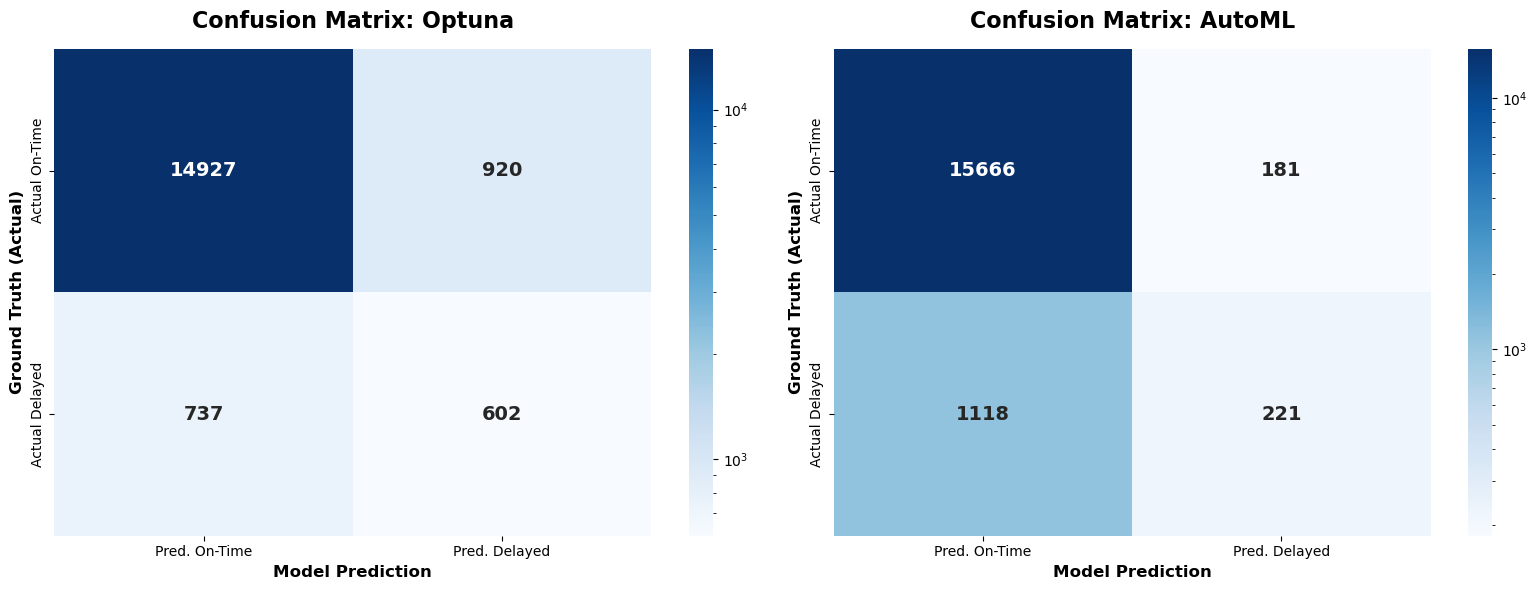

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_opt = confusion_matrix(y_test, y_pred_opt)
cm_aml = confusion_matrix(y_test, y_pred_aml)

sns.heatmap(
    cm_opt, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    norm=LogNorm(),
    xticklabels=['Pred. On-Time', 'Pred. Delayed'], 
    yticklabels=['Actual On-Time', 'Actual Delayed'],
    annot_kws={"size": 14, "weight": "bold"},
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Optuna', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('Ground Truth (Actual)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Model Prediction', fontsize=12, fontweight='bold')

sns.heatmap(
    cm_aml, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    norm=LogNorm(),
    xticklabels=['Pred. On-Time', 'Pred. Delayed'], 
    yticklabels=['Actual On-Time', 'Actual Delayed'],
    annot_kws={"size": 14, "weight": "bold"},
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix: AutoML', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('Ground Truth (Actual)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model Prediction', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7: Save Model

In [21]:
# Ensure the directory exists
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Define the model path; joblib is often more efficient for large NumPy arrays
model_file_path = os.path.join(models_dir, 'lgbm_logistics_model_opt.joblib')

# Serialize the model
joblib.dump(lgbm_model_opt, model_file_path)

print(f"Model successfully saved to: {model_file_path}")

Model successfully saved to: ../models/lgbm_logistics_model_opt.joblib


In [22]:
# Ensure the directory exists
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Define the model path; joblib is often more efficient for large NumPy arrays
model_file_path = os.path.join(models_dir, 'lgbm_logistics_model_aml.joblib')

# Serialize the model
joblib.dump(lgbm_model_aml, model_file_path)

print(f"Model successfully saved to: {model_file_path}")

Model successfully saved to: ../models/lgbm_logistics_model_aml.joblib
